# Transmission spectra: models

In this notebook, we will use `petitRADTRANS` to generate the models of transmission spectra. We will use the example of TOI-396 b to do this. There are two ways to create spectra (both transmission and emission) in `petitRADTRANS`: one using the `Radtrans` object and compute transit radii out of it. The second is to use `SpectralModel` class. We will demonstrate both methods to create transmission spectra.

We need a temperature profile to generate the spectrum. We will use the isothermal profile first, then we will redo the calculations with other available profiles.

The atmosphere has the following chemical structure: H2 and He are dominant gases with mass fractions of 0.74 and 0.14. The other gases present in the atmosphere are SiO (0.1), SiH4 (0.001), CO2 (1e-5), and CH4 (1e-4).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from petitRADTRANS.radtrans import Radtrans
from petitRADTRANS.spectral_model import SpectralModel
from petitRADTRANS.chemistry.utils import compute_mean_molar_masses
from petitRADTRANS.plotlib import plot_opacity_contributions
from petitRADTRANS.planet import Planet
import astropy.units as u
from krithika import plotstyles
import seaborn as sns

from matplotlib import rcParams
rcParams['figure.dpi'] = 300

Let's first create and load planet: this will fetch the planetary data from NASA Exoplanet Archive. All the parameters would be in CGS units.

In [2]:
toi396b = Planet.get(name='HR 858 b')

## Abundances
co2, ch4 = 1000e-6, 100e-6
h2 = 0.755
he = 1 - h2 - co2 - ch4

## Method 1: `Radtrans`

We will use `Radtrans` object, which we will use to load opacities. It will have line species, rayleigh species, and gas continuum contributors. We will specify pressures and wavelength range.

After loading `Radtrans` object, we will create temperature pressure profile (isothermal in this case) and abundances (constant abundances throughout the atmosphere in this case).

Loading Radtrans opacities...
 Loading line opacities of species 'CO2' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CO2/12C-16O2/12C-16O2__UCL-4000.R1000_0.3-50mu.ktable.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'CH4' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CH4/12C-1H4/12C-1H4__HITEMP.R1000_0.1-250mu.ktable.petitRADTRANS.h5'... Done.
 Successfully loaded all line opacities
 Loading CIA opacities for H2--H2 from file '/Users/jaspa/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--H2/H2--H2-NatAbund/H2--H2-NatAbund__BoRi.R831_0.6-250mu.ciatable.petitRADTRANS.h5'... Done.
 Loading CIA opacities for H2--He from file '/Users/jaspa/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--He/H2--He-NatAbund/H2--He-NatAbund__BoRi.DeltaWavenumber2_0.5-500mu.ciatable.petitRADTRANS.h5'... Done.
 Successfully loaded all CIA opacities
Successfully loaded all 

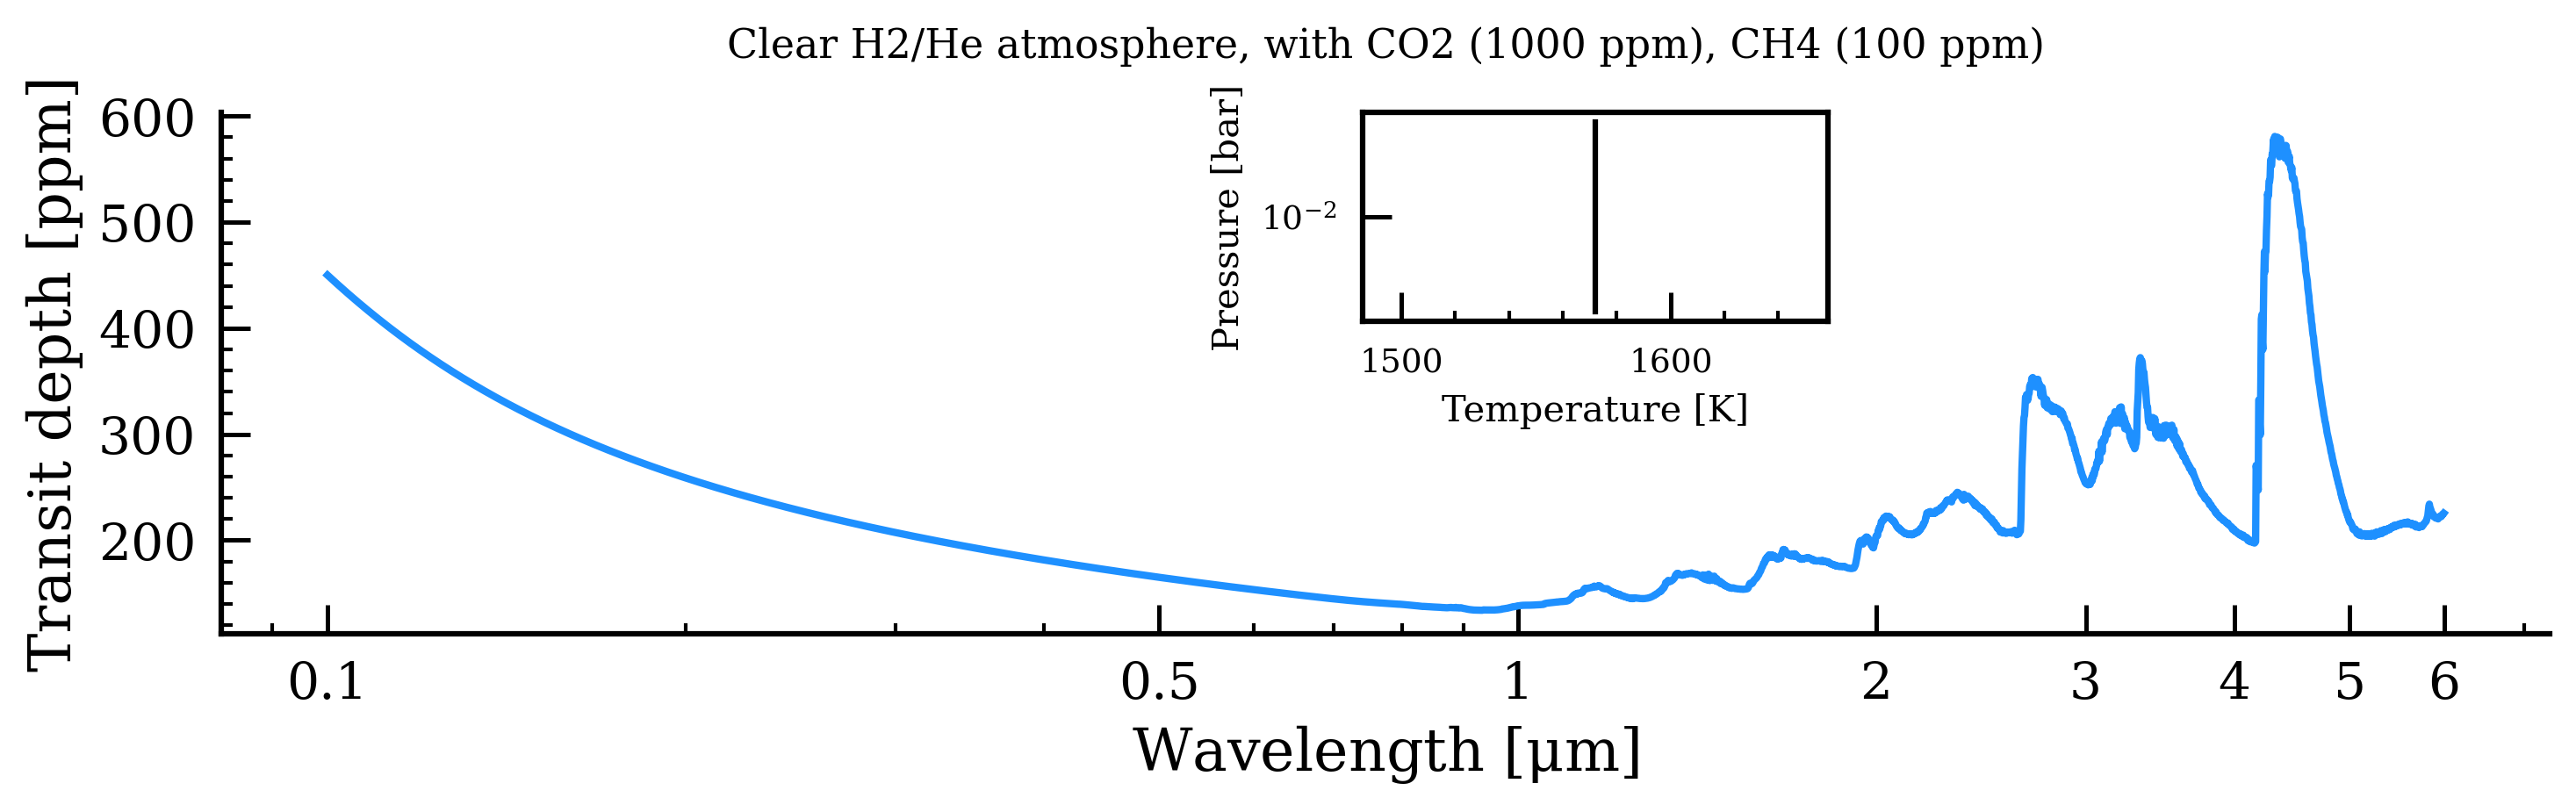

In [3]:
# ----------------------------------------
#         Radtrans object
# ----------------------------------------
radtrans = Radtrans(
    pressures=np.logspace(-6, 2, 100), # The units here are bar
    line_species=[
        'CO2',
        'CH4'
    ],
    rayleigh_species=['H2', 'He'],
    gas_continuum_contributors=['H2--H2', 'H2--He'],
    wavelength_boundaries=[0.1, 6]
)


# ----------------------------------------
#    Temperature profile (isothermal)
# ----------------------------------------
pressures = radtrans.pressures * 1e-6 # radtrans.pressures is in dyne/cm2, multiplying it with 1e-6 to convert it to bar
temperatures = toi396b.equilibrium_temperature * np.ones_like(pressures)

# -------------------------------------------------
#    Abundance profiles (constant with altitude)
# -------------------------------------------------
# Abundances (in units of mass fractions)
mass_fractions = {
    'H2': h2 * np.ones(temperatures.size),
    'He': he * np.ones(temperatures.size),
    'CO2': co2 * np.ones(temperatures.size),
    'CH4': ch4 * np.ones(temperatures.size)
}

# Mean molar masses
mmw = compute_mean_molar_masses(abundances=mass_fractions, mode='mmr')

# -------------------------------------------------
#    Calculating the transit radii
# -------------------------------------------------

wave_iso, transit_radii_iso, _ = radtrans.calculate_transit_radii(
    temperatures=temperatures,
    mass_fractions=mass_fractions,
    mean_molar_masses=mmw,
    reference_gravity=toi396b.reference_gravity,
    planet_radius=toi396b.radius,
    reference_pressure=toi396b.reference_pressure
)

# Wavelengths will be in the units of cm --> we need to convert them to micron
# transit radii will be in the units of cm --> we need to convert them to Rp/R*

wave_iso = ( wave_iso * u.cm ).to(u.micron).value
rprs_iso = transit_radii_iso / toi396b.star_radius

# -------------------------------------------------
#.     Saving the data
# -------------------------------------------------
np.savetxt('Data/toi396b_transit_spectrum_isothermal.txt', np.array([wave_iso, ( rprs_iso**2 ) * 1e6]).T, header='Wavelength [micron], Transit radius [Rp/R*]')

# -------------------------------------------------
#    Plotting the results
# -------------------------------------------------
# And plotting it:
fig, axs = plt.subplots(figsize = (15/1.5, 5/1.5))
axins = axs.inset_axes([0.49, 0.6, 0.2, 0.4])#, visible=True)
axins.set_yscale('log')

axs.plot(wave_iso, ( rprs_iso**2 ) * 1e6, color='dodgerblue')
axins.plot(temperatures, pressures, 'k-', lw=1.5)

axs.set_xscale('log')
axs.set_xlabel(r'Wavelength [$\mu$m]')
axs.set_ylabel(r'Transit depth [ppm]')

axs.set_title('Clear H2/He atmosphere, with CO2 ({:.0f} ppm), CH4 ({:.0f} ppm)'.format(co2*1e6, ch4*1e6), fontsize=11, y=1.05)

axins.set_xlabel('Temperature [K]', fontsize=10)
axins.set_ylabel('Pressure [bar]', fontsize=10)

axs.set_xticks(ticks=np.array([0.1, 0.5, 1., 2., 3., 4., 5., 6.,]),\
              labels=np.array(['0.1', '0.5', '1', '2', '3', '4', '5', '6']))

#axs.text(1, 500, 'Isothermal profile', color='dodgerblue')

axins.invert_yaxis()
plt.setp(axins.get_xticklabels(), fontsize=9)
plt.setp(axins.get_yticklabels(), fontsize=9)

axs.spines[['right', 'top']].set_visible(False)

plt.tight_layout()

## Method 2: `SpectralModel`

The `SpectralModel` class basically does everything in just one function as shown below (we use the isothermal temperature profile):

Loading Radtrans opacities...
 Loading line opacities of species 'CO2' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CO2/12C-16O2/12C-16O2__UCL-4000.R1000_0.3-50mu.ktable.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'CH4' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CH4/12C-1H4/12C-1H4__HITEMP.R1000_0.1-250mu.ktable.petitRADTRANS.h5'... Done.
 Successfully loaded all line opacities
 Loading CIA opacities for H2--H2 from file '/Users/jaspa/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--H2/H2--H2-NatAbund/H2--H2-NatAbund__BoRi.R831_0.6-250mu.ciatable.petitRADTRANS.h5'... Done.
 Loading CIA opacities for H2--He from file '/Users/jaspa/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--He/H2--He-NatAbund/H2--He-NatAbund__BoRi.DeltaWavenumber2_0.5-500mu.ciatable.petitRADTRANS.h5'... Done.
 Successfully loaded all CIA opacities
Successfully loaded all 

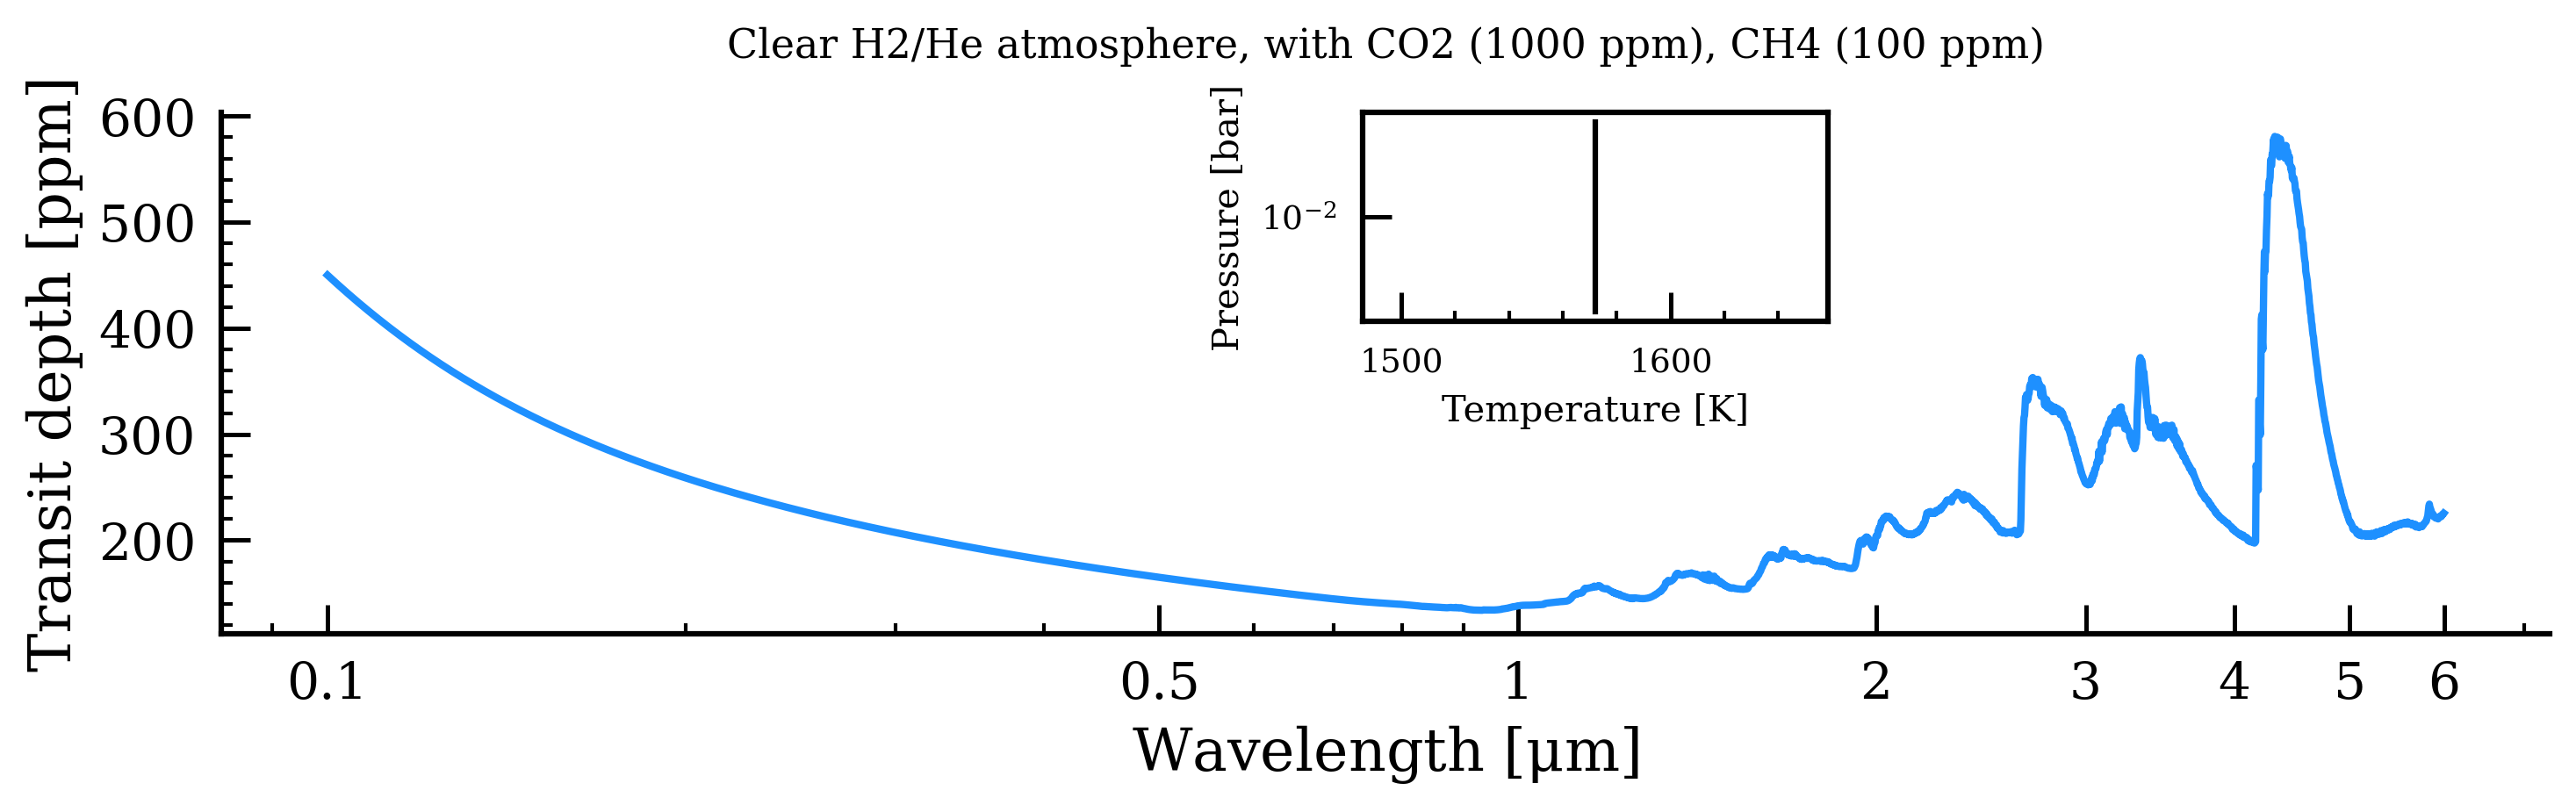

In [4]:
# -------------------------------------------------
#    Plotting the results
# -------------------------------------------------

spectral_model_iso = SpectralModel(
    # Radtrans parameters
    pressures=np.logspace(-6, 2, 100),
    line_species=[
        'CO2',
        'CH4'
    ],
    rayleigh_species=['H2', 'He'],
    gas_continuum_contributors=['H2--H2', 'H2--He'],
    wavelength_boundaries=[0.1, 6],
    
    # Model parameters
    ## Planet parameters
    planet_radius=toi396b.radius,
    reference_gravity=toi396b.reference_gravity,
    reference_pressure=toi396b.reference_pressure,
    
    ## Temperature profile parameters
    temperature=toi396b.equilibrium_temperature,  # isothermal temperature profile
    
    # Mass fractions
    imposed_mass_fractions={  # these can also be arrays of the same size as pressures
        'CO2': co2,
        'CH4': ch4
    },
    filling_species={  # automatically fill the atmosphere with H2 and He, such that the sum of MMRs is equal to 1 and H2/He = 37/12
        'H2': h2,
        'He': he
    }
)

# -------------------------------------------------
#    Calculating the transit radii
# -------------------------------------------------

# Computing the transmission spectrum
wave_spec_iso, transit_radii_spec_iso = spectral_model_iso.calculate_spectrum(
    mode='transmission'
)

## Converting units
wave_spec_iso = ( wave_spec_iso[0,:] * u.cm ).to(u.micron).value
rprs_spec_iso = transit_radii_spec_iso[0,:] / toi396b.star_radius

# -------------------------------------------------
#    Plotting the results
# -------------------------------------------------

# And plotting it:
fig, axs = plt.subplots(figsize = (15/1.5, 5/1.5))
axins = axs.inset_axes([0.49, 0.6, 0.2, 0.4])#, visible=True)
axins.set_yscale('log')

axs.plot(wave_spec_iso, ( rprs_spec_iso**2 ) * 1e6, color='dodgerblue')
axins.plot(spectral_model_iso.temperatures, spectral_model_iso.pressures*1e-6, 'k-', lw=1.5)

axs.set_xscale('log')
axs.set_xlabel(r'Wavelength [$\mu$m]')
axs.set_ylabel(r'Transit depth [ppm]')

axins.set_xlabel('Temperature [K]', fontsize=10)
axins.set_ylabel('Pressure [bar]', fontsize=10)

axs.set_title('Clear H2/He atmosphere, with CO2 ({:.0f} ppm), CH4 ({:.0f} ppm)'.format(co2*1e6, ch4*1e6), fontsize=11, y=1.05)

axs.set_xticks(ticks=np.array([0.1, 0.5, 1., 2., 3., 4., 5., 6.,]),\
              labels=np.array(['0.1', '0.5', '1', '2', '3', '4', '5', '6']))

#axs.text(1, 500, 'Isothermal profile', color='dodgerblue')
axins.invert_yaxis()
plt.setp(axins.get_xticklabels(), fontsize=9)
plt.setp(axins.get_yticklabels(), fontsize=9)

axs.spines[['right', 'top']].set_visible(False)

plt.tight_layout()

Here are the opacity contribution:

Generating temporary Radtrans object with 'line_species': 'CO2'
Loading Radtrans opacities...
 Loading line opacities of species 'CO2' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CO2/12C-16O2/12C-16O2__UCL-4000.R1000_0.3-50mu.ktable.petitRADTRANS.h5'... Done.
 Successfully loaded all line opacities
Successfully loaded all opacities
Loading Radtrans opacities...
 Loading line opacities of species 'CO2' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CO2/12C-16O2/12C-16O2__UCL-4000.R1000_0.3-50mu.ktable.petitRADTRANS.h5'... Done.
 Successfully loaded all line opacities
Successfully loaded all opacities
Generating temporary Radtrans object with 'line_species': 'CH4'
Loading Radtrans opacities...
 Loading line opacities of species 'CH4' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CH4/12C-1H4/12C-1H4__HITEMP.R1000_0.1-250mu.ktable.petitRADTRANS.h5'... Done.
 Successfully loaded all line opaciti

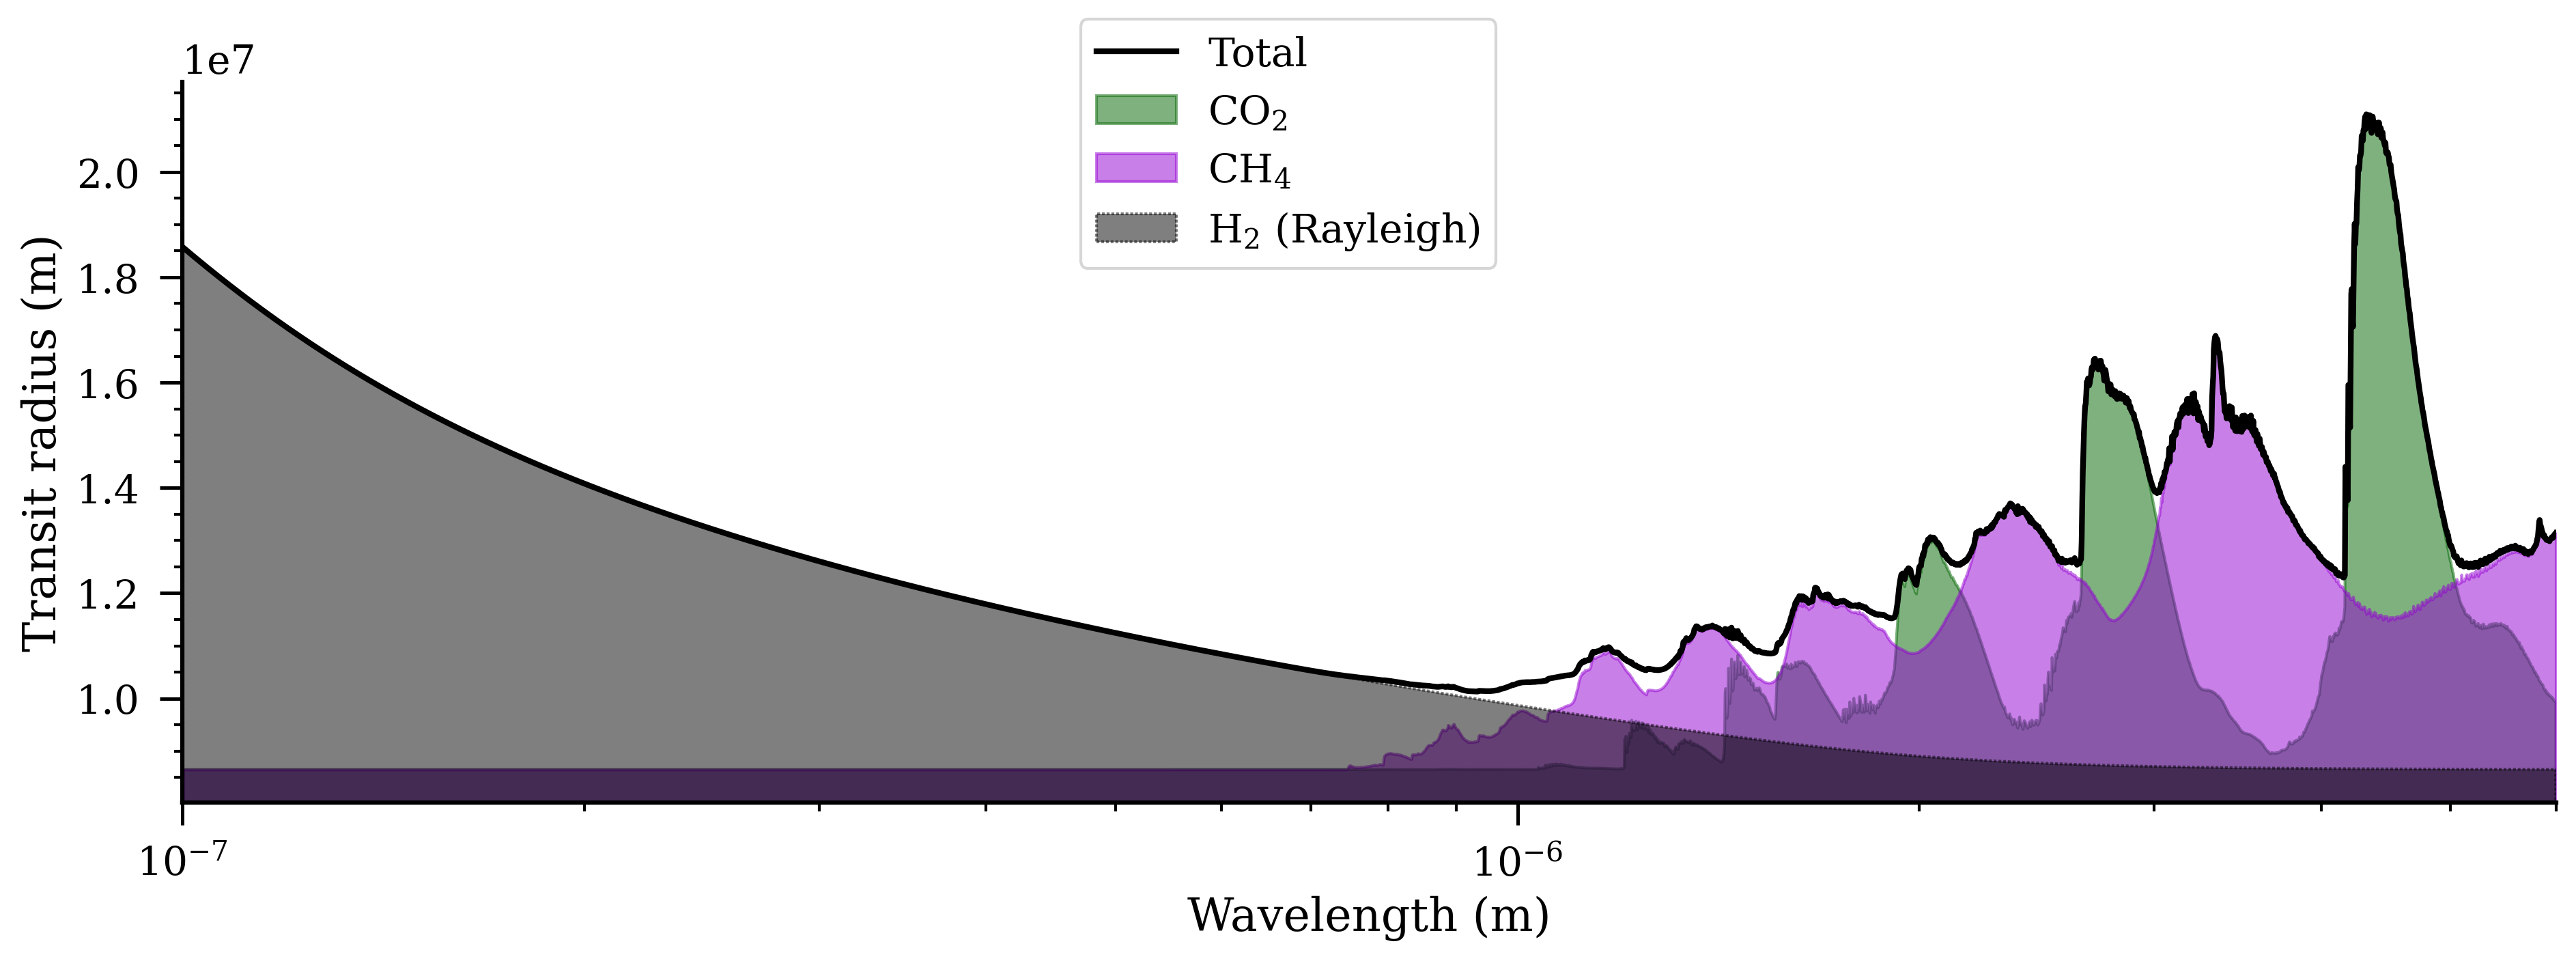

In [5]:
rcParams['legend.loc'] = 'upper center'
rcParams['legend.frameon'] = True
rcParams['xtick.direction'] = 'out'
rcParams['ytick.direction'] = 'out'

opacity_contributions = plot_opacity_contributions(
    radtrans,
    mode='transmission',  # can also be 'emission'
    exclude=['He (Rayleigh)', 'H2--H2', 'H2--He'],
    colors={
        'Total': 'k',
        'line_species': {
            'CO2' : 'darkgreen',
            'CH4' : 'darkviolet'
        }
    },
    fill_below=True,  # if False, contributions are represented as cruves instead as a filled area
    x_axis_scale='log',  # 'linear' by default
    temperatures=spectral_model_iso.temperatures,
    mass_fractions=spectral_model_iso.mass_fractions,
    mean_molar_masses=spectral_model_iso.mean_molar_masses,
    reference_gravity=toi396b.reference_gravity,
    planet_radius=toi396b.radius,
    reference_pressure=toi396b.reference_pressure,
    fill_alpha = 0.5
)

sns.despine()

Okay with the use of UV and IR spectra, we should be able to detect

### Guillot (2010) profile

Loading Radtrans opacities...
 Loading line opacities of species 'CO2' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CO2/12C-16O2/12C-16O2__UCL-4000.R1000_0.3-50mu.ktable.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'CH4' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CH4/12C-1H4/12C-1H4__HITEMP.R1000_0.1-250mu.ktable.petitRADTRANS.h5'... Done.
 Successfully loaded all line opacities
 Loading CIA opacities for H2--H2 from file '/Users/jaspa/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--H2/H2--H2-NatAbund/H2--H2-NatAbund__BoRi.R831_0.6-250mu.ciatable.petitRADTRANS.h5'... Done.
 Loading CIA opacities for H2--He from file '/Users/jaspa/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--He/H2--He-NatAbund/H2--He-NatAbund__BoRi.DeltaWavenumber2_0.5-500mu.ciatable.petitRADTRANS.h5'... Done.
 Successfully loaded all CIA opacities
Successfully loaded all 

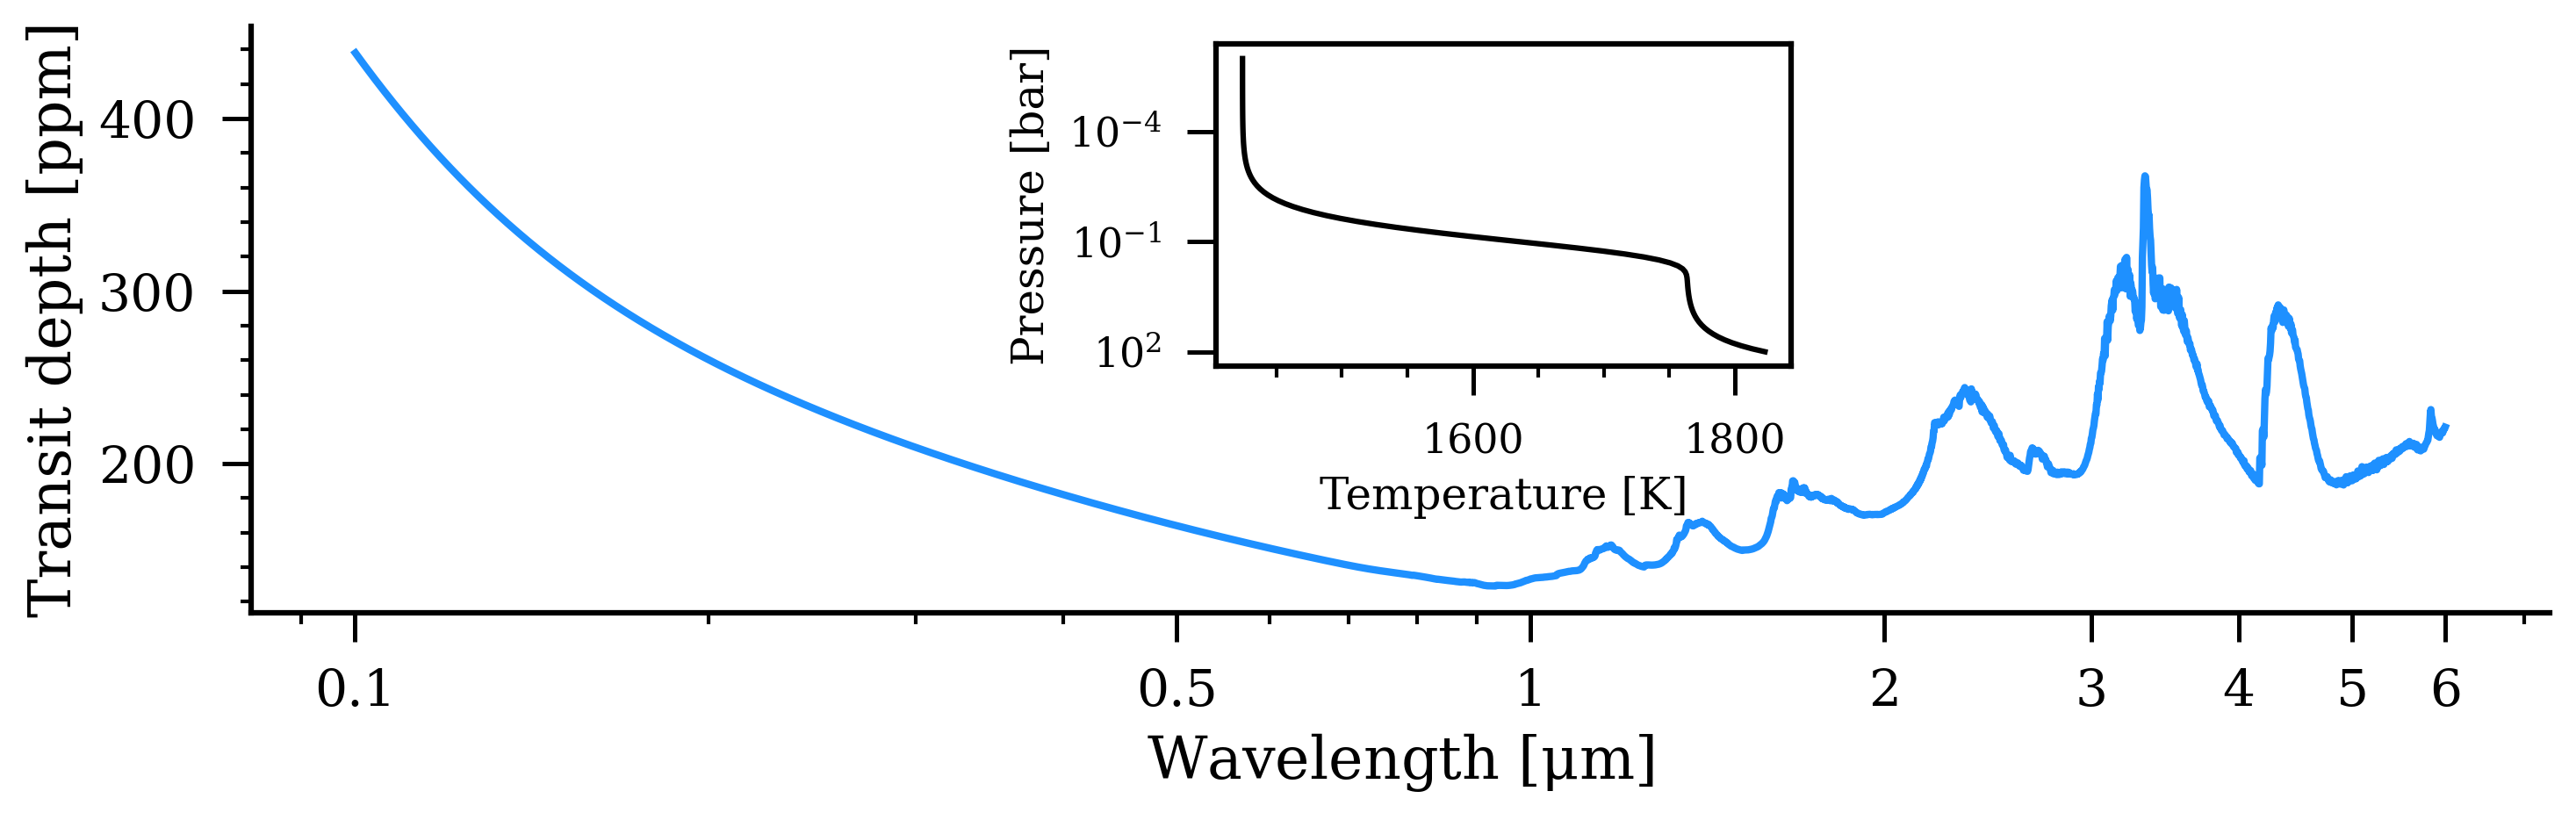

In [6]:
spectral_model_guillot = SpectralModel(
    # Radtrans parameters
    pressures=np.logspace(-6, 2, 100),
    line_species=[
        'CO2',
        'CH4'
    ],
    rayleigh_species=['H2', 'He'],
    gas_continuum_contributors=['H2--H2', 'H2--He'],
    wavelength_boundaries=[0.1, 6],
    
    # Model parameters
    ## Planet parameters
    planet_radius=toi396b.radius,
    reference_gravity=toi396b.reference_gravity,
    reference_pressure=toi396b.reference_pressure,
    
    # Temperature profile parameters
    temperature_profile_mode='guillot',
    temperature=toi396b.equilibrium_temperature,
    intrinsic_temperature=200,
    guillot_temperature_profile_gamma=0.4,
    guillot_temperature_profile_infrared_mean_opacity_solar_metallicity=0.01,
    
    # Mass fractions
    imposed_mass_fractions={  # these can also be arrays of the same size as pressures
        'CO2': 1e-5,
        'CH4': 1e-4
    },
    filling_species={  # automatically fill the atmosphere with H2 and He, such that the sum of MMRs is equal to 1 and H2/He = 37/12
        'H2': 75.5,
        'He': 14
    }
)

# Computing the transmission spectrum
wave_spec_guillot, transit_radii_spec_guillot = spectral_model_guillot.calculate_spectrum(
    mode='transmission'
)

## Converting units
wave_spec_guillot = ( wave_spec_guillot[0,:] * u.cm ).to(u.micron).value
rprs_spec_guillot = transit_radii_spec_guillot[0,:] / toi396b.star_radius

# -------------------------------------------------
#.     Saving the data
# -------------------------------------------------
np.savetxt('Data/toi396b_transit_spectrum_guillot.txt', np.array([wave_spec_guillot, ( rprs_spec_guillot**2 ) * 1e6]).T, header='Wavelength [micron], Transit radius [Rp/R*]')

# -------------------------------------------------
#    Plotting the results
# -------------------------------------------------
# And plotting it:
fig, axs = plt.subplots(figsize = (15/1.5, 5/1.5))
axins = axs.inset_axes([0.42, 0.42, 0.25, 0.55])#, visible=True)
axins.set_yscale('log')

axs.plot(wave_spec_guillot, ( rprs_spec_guillot**2 ) * 1e6, color='dodgerblue')
axins.plot(spectral_model_guillot.temperatures, spectral_model_guillot.pressures*1e-6, 'k-', lw=1.5)

axs.set_xscale('log')
axs.set_xlabel(r'Wavelength [$\mu$m]')
axs.set_ylabel(r'Transit depth [ppm]')

axins.set_xlabel('Temperature [K]', fontsize=12)
axins.set_ylabel('Pressure [bar]', fontsize=12)

axs.set_xticks(ticks=np.array([0.1, 0.5, 1., 2., 3., 4., 5., 6.,]),\
              labels=np.array(['0.1', '0.5', '1', '2', '3', '4', '5', '6']))

#axs.text(1, 500, 'Isothermal profile', color='dodgerblue')
axins.invert_yaxis()
plt.setp(axins.get_xticklabels(), fontsize=11)
plt.setp(axins.get_yticklabels(), fontsize=11)

axs.spines[['right', 'top']].set_visible(False)

plt.tight_layout()

Alternatively, we can define a function to generate the temperature profile, which we can use as a argument in `model_functions_map`.

Loading Radtrans opacities...
 Loading line opacities of species 'CO2' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CO2/12C-16O2/12C-16O2__UCL-4000.R1000_0.3-50mu.ktable.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'CH4' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CH4/12C-1H4/12C-1H4__HITEMP.R1000_0.1-250mu.ktable.petitRADTRANS.h5'... Done.
 Successfully loaded all line opacities
 Loading CIA opacities for H2--H2 from file '/Users/jaspa/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--H2/H2--H2-NatAbund/H2--H2-NatAbund__BoRi.R831_0.6-250mu.ciatable.petitRADTRANS.h5'... Done.
 Loading CIA opacities for H2--He from file '/Users/jaspa/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--He/H2--He-NatAbund/H2--He-NatAbund__BoRi.DeltaWavenumber2_0.5-500mu.ciatable.petitRADTRANS.h5'... Done.
 Successfully loaded all CIA opacities
Successfully loaded all 

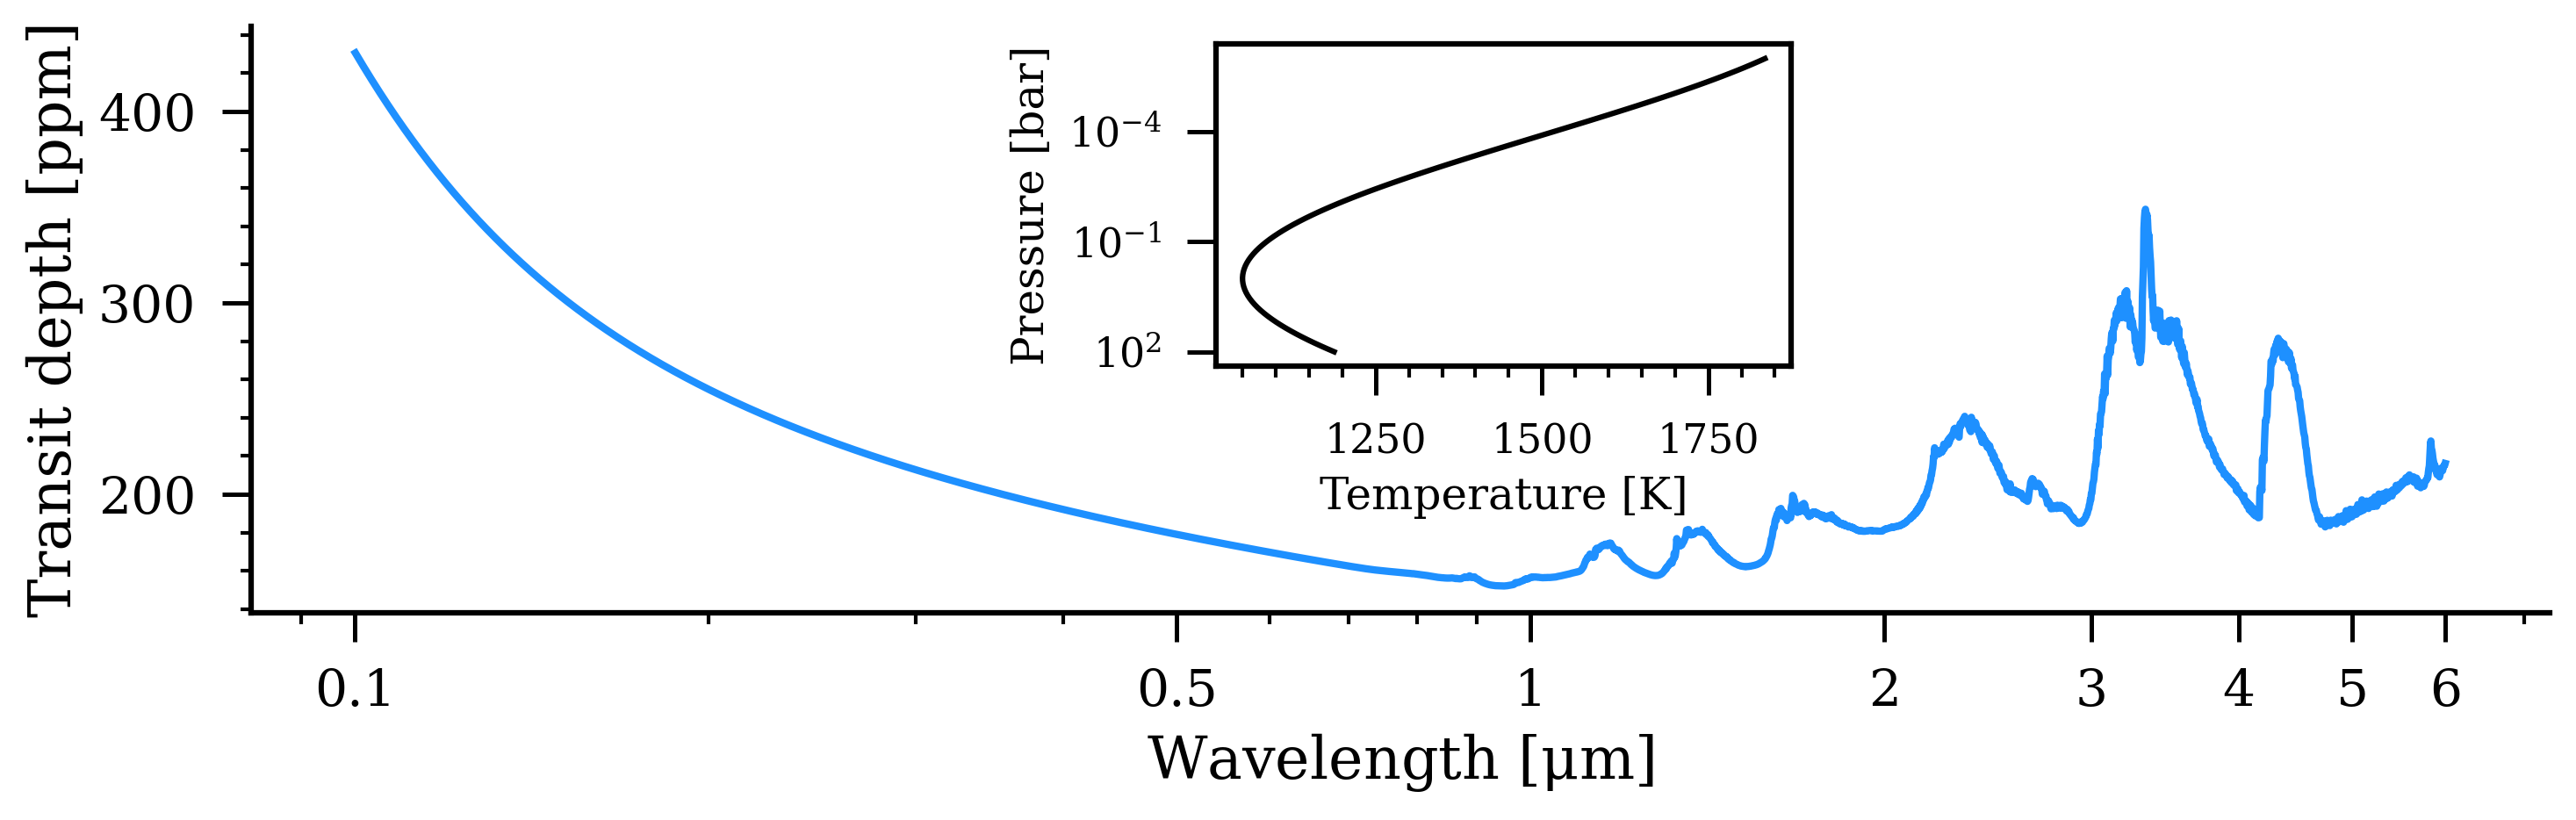

In [7]:
def temp_prof(pressures, a1, a2, **kwargs):
    t1 = a2 * (1 - 0.3 * np.cos(np.deg2rad(a1 * np.log(pressures))))
    return t1

spectral_model_inverted = SpectralModel(
    # Radtrans parameters
    pressures=np.logspace(-6, 2, 100),
    line_species=[
        'CO2',
        'CH4'
    ],
    rayleigh_species=['H2', 'He'],
    gas_continuum_contributors=['H2--H2', 'H2--He'],
    wavelength_boundaries=[0.1, 6],
    
    # Model parameters
    ## Planet parameters
    planet_radius=toi396b.radius,
    reference_gravity=toi396b.reference_gravity,
    reference_pressure=toi396b.reference_pressure,
    
    # Temperature profile parameters
    a1 = 10,
    a2 = 1500,
    model_functions_map={
        'temperatures': temp_prof,  # which function to use to calculate the 'temperatures' spectral parameter
    }, 
    
    # Mass fractions
    imposed_mass_fractions={  # these can also be arrays of the same size as pressures
        'CO2': 1e-5,
        'CH4': 1e-4
    },
    filling_species={  # automatically fill the atmosphere with H2 and He, such that the sum of MMRs is equal to 1 and H2/He = 37/12
        'H2': 75.5,
        'He': 14
    }
)

# Computing the transmission spectrum
wave_spec_inverted, transit_radii_spec_inverted = spectral_model_inverted.calculate_spectrum(
    mode='transmission'
)

## Converting units
wave_spec_inverted = ( wave_spec_inverted[0,:] * u.cm ).to(u.micron).value
rprs_spec_inverted = transit_radii_spec_inverted[0,:] / toi396b.star_radius

# -------------------------------------------------
#.     Saving the data
# -------------------------------------------------
np.savetxt('Data/toi396b_transit_spectrum_inverted.txt', np.array([wave_spec_inverted, ( rprs_spec_inverted**2 ) * 1e6]).T, header='Wavelength [micron], Transit radius [Rp/R*]')

# -------------------------------------------------
#    Plotting the results
# -------------------------------------------------
# And plotting it:
fig, axs = plt.subplots(figsize = (15/1.5, 5/1.5))
axins = axs.inset_axes([0.42, 0.42, 0.25, 0.55])#, visible=True)
axins.set_yscale('log')

axs.plot(wave_spec_inverted, ( rprs_spec_inverted**2 ) * 1e6, color='dodgerblue')
axins.plot(spectral_model_inverted.temperatures, spectral_model_inverted.pressures*1e-6, 'k-', lw=1.5)

axs.set_xscale('log')
axs.set_xlabel(r'Wavelength [$\mu$m]')
axs.set_ylabel(r'Transit depth [ppm]')

axins.set_xlabel('Temperature [K]', fontsize=12)
axins.set_ylabel('Pressure [bar]', fontsize=12)

axs.set_xticks(ticks=np.array([0.1, 0.5, 1., 2., 3., 4., 5., 6.,]),\
              labels=np.array(['0.1', '0.5', '1', '2', '3', '4', '5', '6']))

#axs.text(1, 500, 'Isothermal profile', color='dodgerblue')
axins.invert_yaxis()
plt.setp(axins.get_xticklabels(), fontsize=11)
plt.setp(axins.get_yticklabels(), fontsize=11)

axs.spines[['right', 'top']].set_visible(False)

plt.tight_layout()

## Equilibrium chemistry

Until now, we have been using free chemistry, i.e., providing abundances manually. However, we can use the equilibrium chemistry to provide the chemical abundances of the species.

Loading Radtrans opacities...
 Loading line opacities of species 'CO2' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CO2/12C-16O2/12C-16O2__UCL-4000.R1000_0.3-50mu.ktable.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'CH4' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CH4/12C-1H4/12C-1H4__HITEMP.R1000_0.1-250mu.ktable.petitRADTRANS.h5'... Done.
 Successfully loaded all line opacities
 Loading CIA opacities for H2--H2 from file '/Users/jaspa/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--H2/H2--H2-NatAbund/H2--H2-NatAbund__BoRi.R831_0.6-250mu.ciatable.petitRADTRANS.h5'... Done.
 Loading CIA opacities for H2--He from file '/Users/jaspa/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--He/H2--He-NatAbund/H2--He-NatAbund__BoRi.DeltaWavenumber2_0.5-500mu.ciatable.petitRADTRANS.h5'... Done.
 Successfully loaded all CIA opacities
Successfully loaded all 

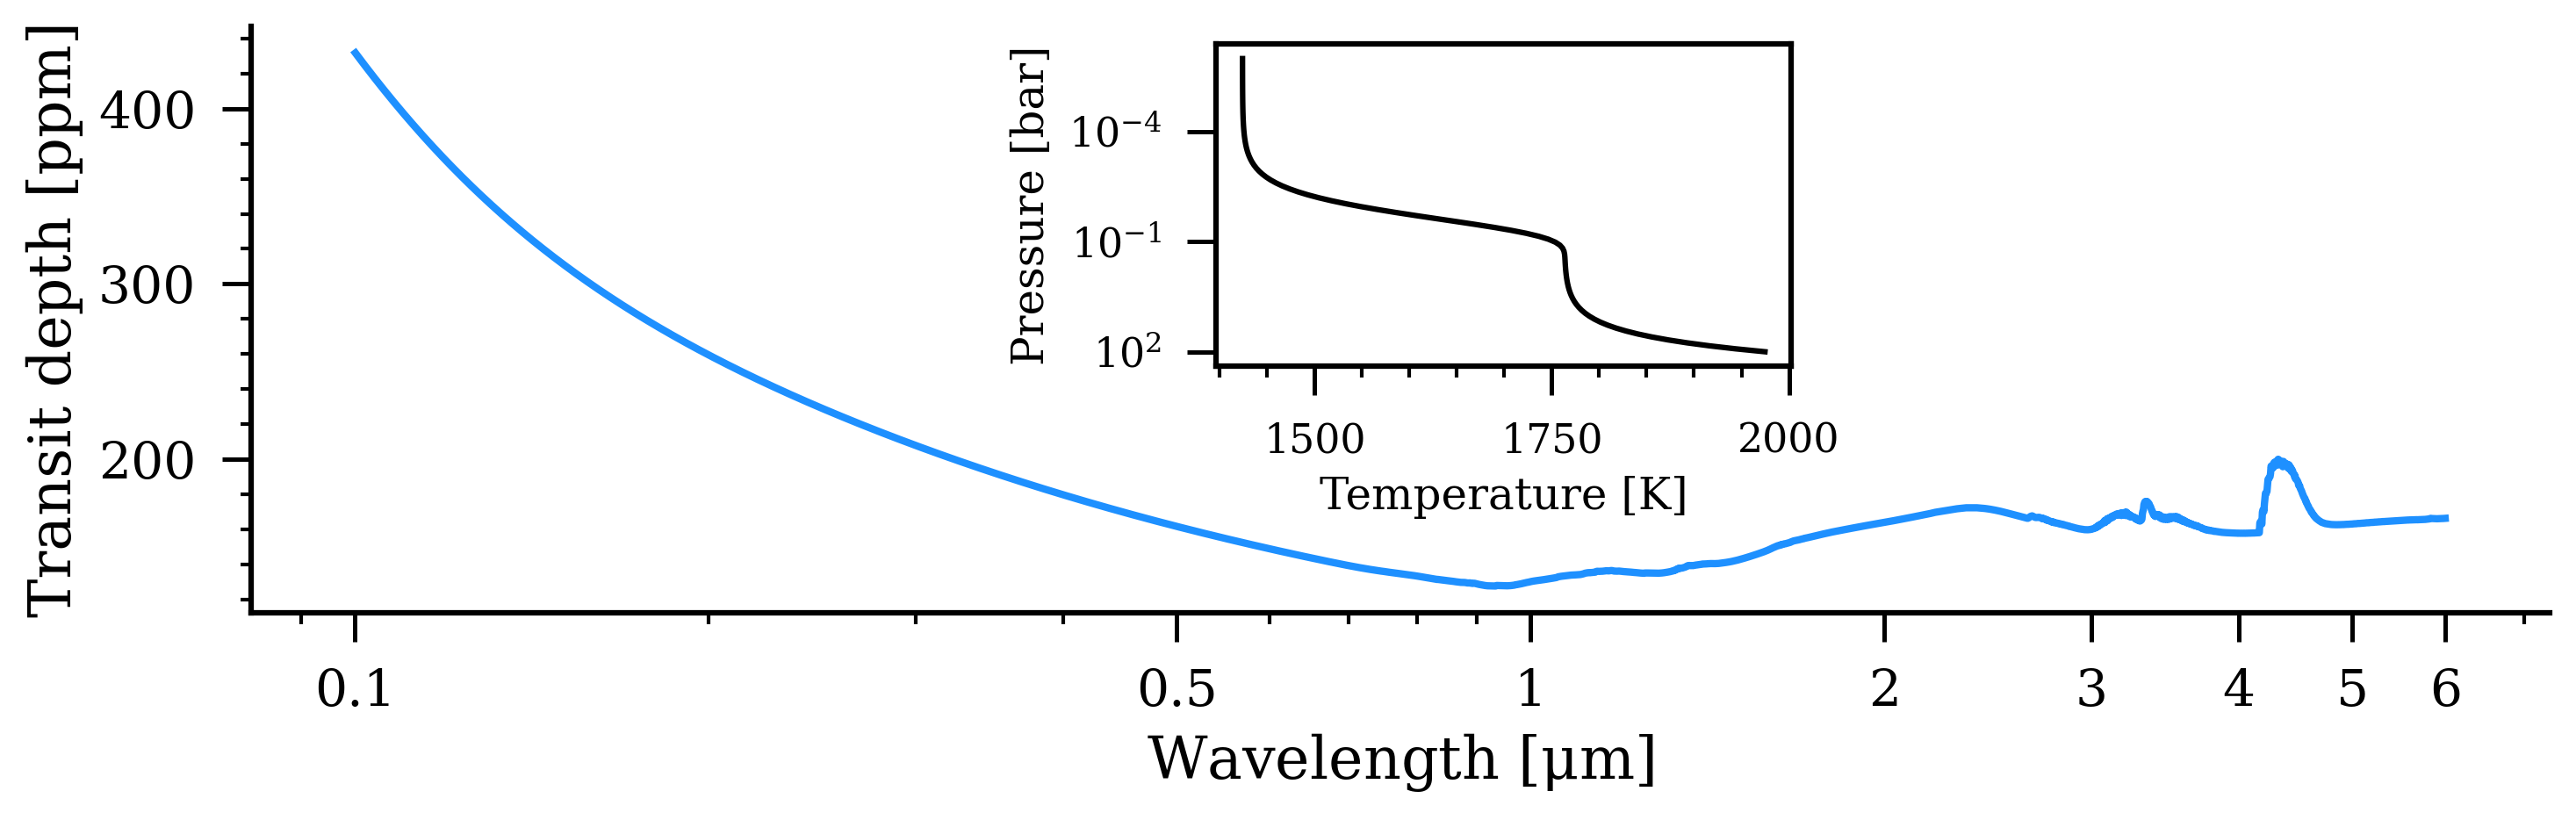

In [8]:
spectral_model_chem_eq = SpectralModel(
    # Radtrans parameters
    pressures=np.logspace(-6, 2, 100),
    line_species=[
        'CO2',
        'CH4'
    ],
    rayleigh_species=['H2', 'He'],
    gas_continuum_contributors=['H2--H2', 'H2--He'],
    wavelength_boundaries=[0.1, 6],
    
    # Model parameters
    ## Planet parameters
    planet_radius=toi396b.radius,
    reference_gravity=toi396b.reference_gravity,
    reference_pressure=toi396b.reference_pressure,
    
    # Temperature profile parameters
    temperature_profile_mode='guillot',
    temperature=toi396b.equilibrium_temperature,
    intrinsic_temperature=200,
    guillot_temperature_profile_gamma=0.4,
    guillot_temperature_profile_infrared_mean_opacity_solar_metallicity=0.01,
    
    # Mass fractions
    use_equilibrium_chemistry=True,
    metallicity=4,  # times solar
    co_ratio=0.9,

    filling_species={  # automatically fill the atmosphere with H2 and He, such that the sum of MMRs is equal to 1 and H2/He = 37/12
        'H2': 75.5,
        'He': 14
    }
)

# Computing the transmission spectrum
wave_spec_chem_eq, transit_radii_chem_eq = spectral_model_chem_eq.calculate_spectrum(
    mode='transmission'
)

## Converting units
wave_spec_chem_eq = ( wave_spec_chem_eq[0,:] * u.cm ).to(u.micron).value
rprs_spec_chem_eq = transit_radii_chem_eq[0,:] / toi396b.star_radius

# -------------------------------------------------
#.     Saving the data
# -------------------------------------------------
np.savetxt('Data/toi396b_transit_spectrum_chem_eq.txt', np.array([wave_spec_chem_eq, ( rprs_spec_chem_eq**2 ) * 1e6]).T, header='Wavelength [micron], Transit radius [Rp/R*]')

# -------------------------------------------------
#    Plotting the results
# -------------------------------------------------
# And plotting it:
fig, axs = plt.subplots(figsize = (15/1.5, 5/1.5))
axins = axs.inset_axes([0.42, 0.42, 0.25, 0.55])#, visible=True)
axins.set_yscale('log')

axs.plot(wave_spec_chem_eq, ( rprs_spec_chem_eq**2 ) * 1e6, color='dodgerblue')
axins.plot(spectral_model_chem_eq.temperatures, spectral_model_chem_eq.pressures*1e-6, 'k-', lw=1.5)

axs.set_xscale('log')
axs.set_xlabel(r'Wavelength [$\mu$m]')
axs.set_ylabel(r'Transit depth [ppm]')

axins.set_xlabel('Temperature [K]', fontsize=12)
axins.set_ylabel('Pressure [bar]', fontsize=12)

axs.set_xticks(ticks=np.array([0.1, 0.5, 1., 2., 3., 4., 5., 6.,]),\
              labels=np.array(['0.1', '0.5', '1', '2', '3', '4', '5', '6']))

#axs.text(1, 500, 'Isothermal profile', color='dodgerblue')
axins.invert_yaxis()
plt.setp(axins.get_xticklabels(), fontsize=11)
plt.setp(axins.get_yticklabels(), fontsize=11)

axs.spines[['right', 'top']].set_visible(False)

plt.tight_layout()

And this is how the chemical abundances (in form of mass fractions) varies with pressure:

Text(0, 0.5, 'P [bar]')

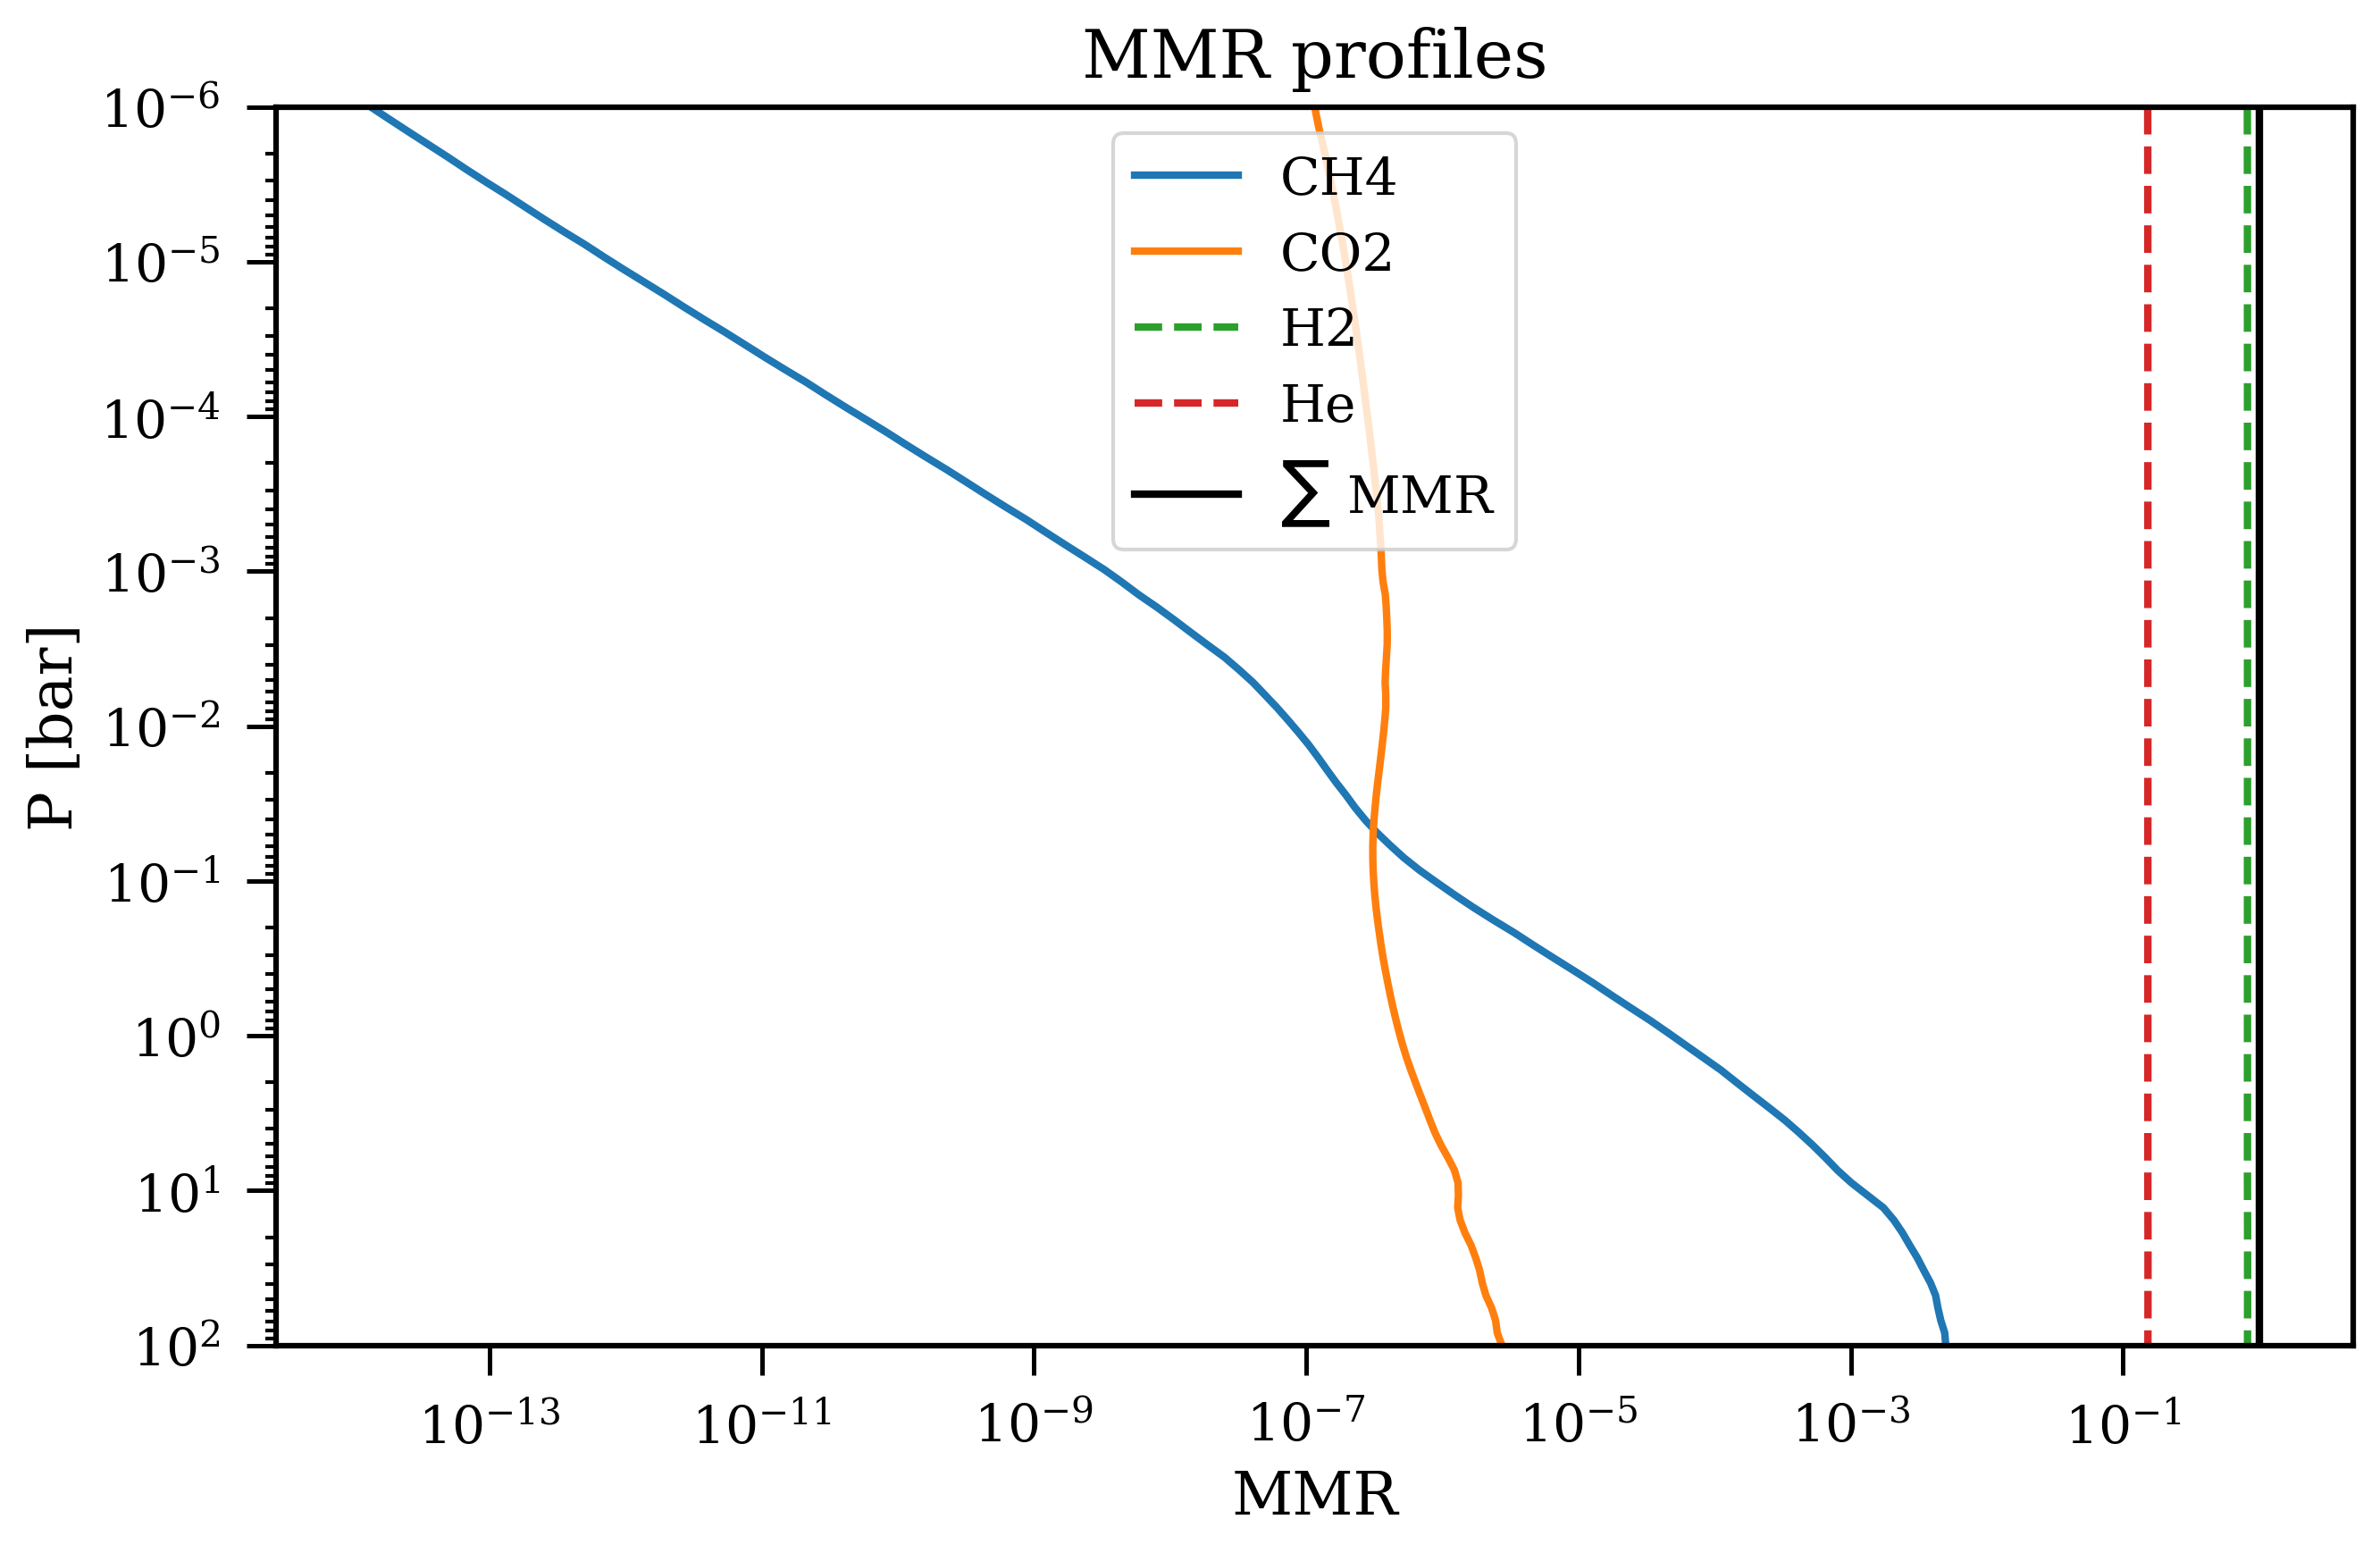

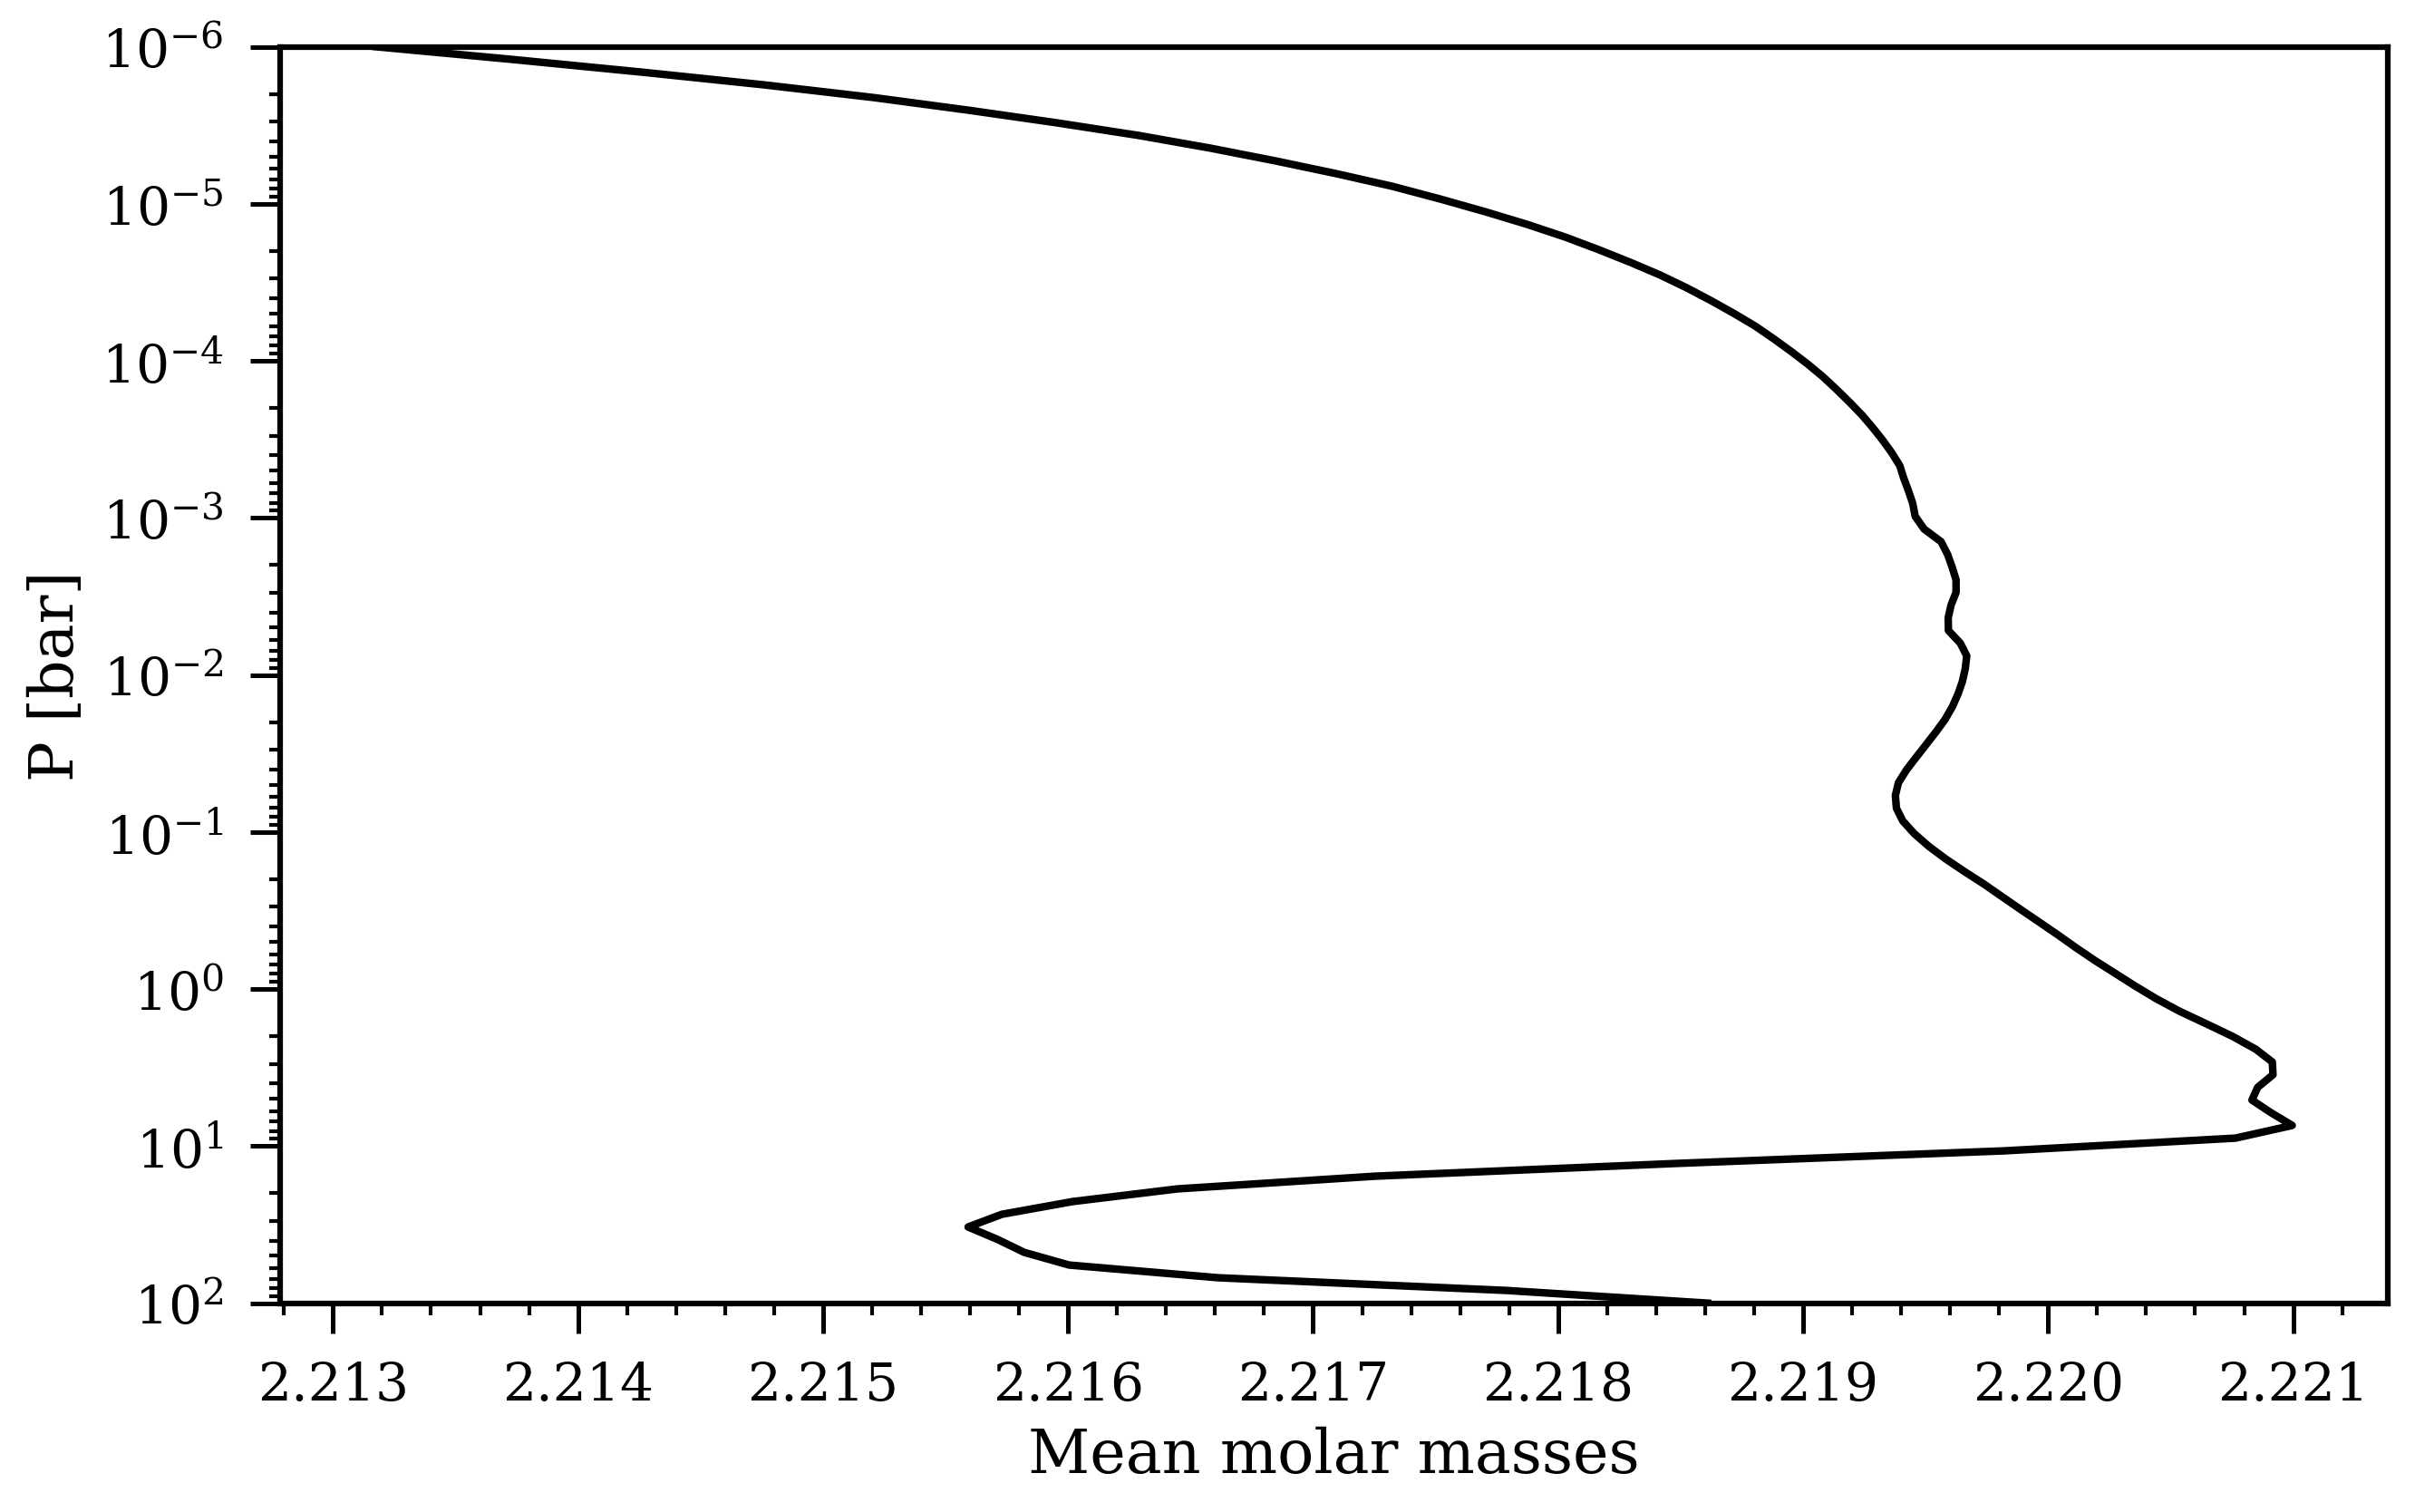

In [9]:
fig, ax = plt.subplots(figsize = (10,6))

for species, mass_fraction in spectral_model_chem_eq.mass_fractions.items():
    if species in spectral_model_chem_eq.line_species:
        ax.loglog(mass_fraction, spectral_model_chem_eq.pressures * 1e-6, label=species)

for species, mass_fraction in spectral_model_chem_eq.mass_fractions.items():
    if species in spectral_model_chem_eq.model_parameters['filling_species']:
        ax.loglog(mass_fraction, spectral_model_chem_eq.pressures * 1e-6, label=species, ls='--')

ax.loglog(np.sum(list(spectral_model_chem_eq.mass_fractions.values()), axis=0), spectral_model_chem_eq.pressures * 1e-6, label=r'$\sum$ MMR', color='k')

ax.set_ylim([1e2, 1e-6])
ax.set_title('MMR profiles')
ax.set_xlabel('MMR')
ax.set_ylabel('P [bar]')
ax.legend()

fig, ax = plt.subplots(figsize = (10,6))
ax.semilogy(spectral_model_chem_eq.mean_molar_masses, spectral_model_chem_eq.pressures * 1e-6, 'k-')
ax.set_ylim([1e2, 1e-6])
ax.set_xlabel('Mean molar masses')
ax.set_ylabel('P [bar]')

We can also find the opacity contributions from various molecules.

Loading Radtrans opacities...
 Loading line opacities of species 'CO2' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CO2/12C-16O2/12C-16O2__UCL-4000.R1000_0.3-50mu.ktable.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'CH4' from file '/Users/jaspa/petitRADTRANS/input_data/opacities/lines/correlated_k/CH4/12C-1H4/12C-1H4__HITEMP.R1000_0.1-250mu.ktable.petitRADTRANS.h5'... Done.
 Successfully loaded all line opacities
 Loading CIA opacities for H2--H2 from file '/Users/jaspa/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--H2/H2--H2-NatAbund/H2--H2-NatAbund__BoRi.R831_0.6-250mu.ciatable.petitRADTRANS.h5'... Done.
 Loading CIA opacities for H2--He from file '/Users/jaspa/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--He/H2--He-NatAbund/H2--He-NatAbund__BoRi.DeltaWavenumber2_0.5-500mu.ciatable.petitRADTRANS.h5'... Done.
 Successfully loaded all CIA opacities
Successfully loaded all 

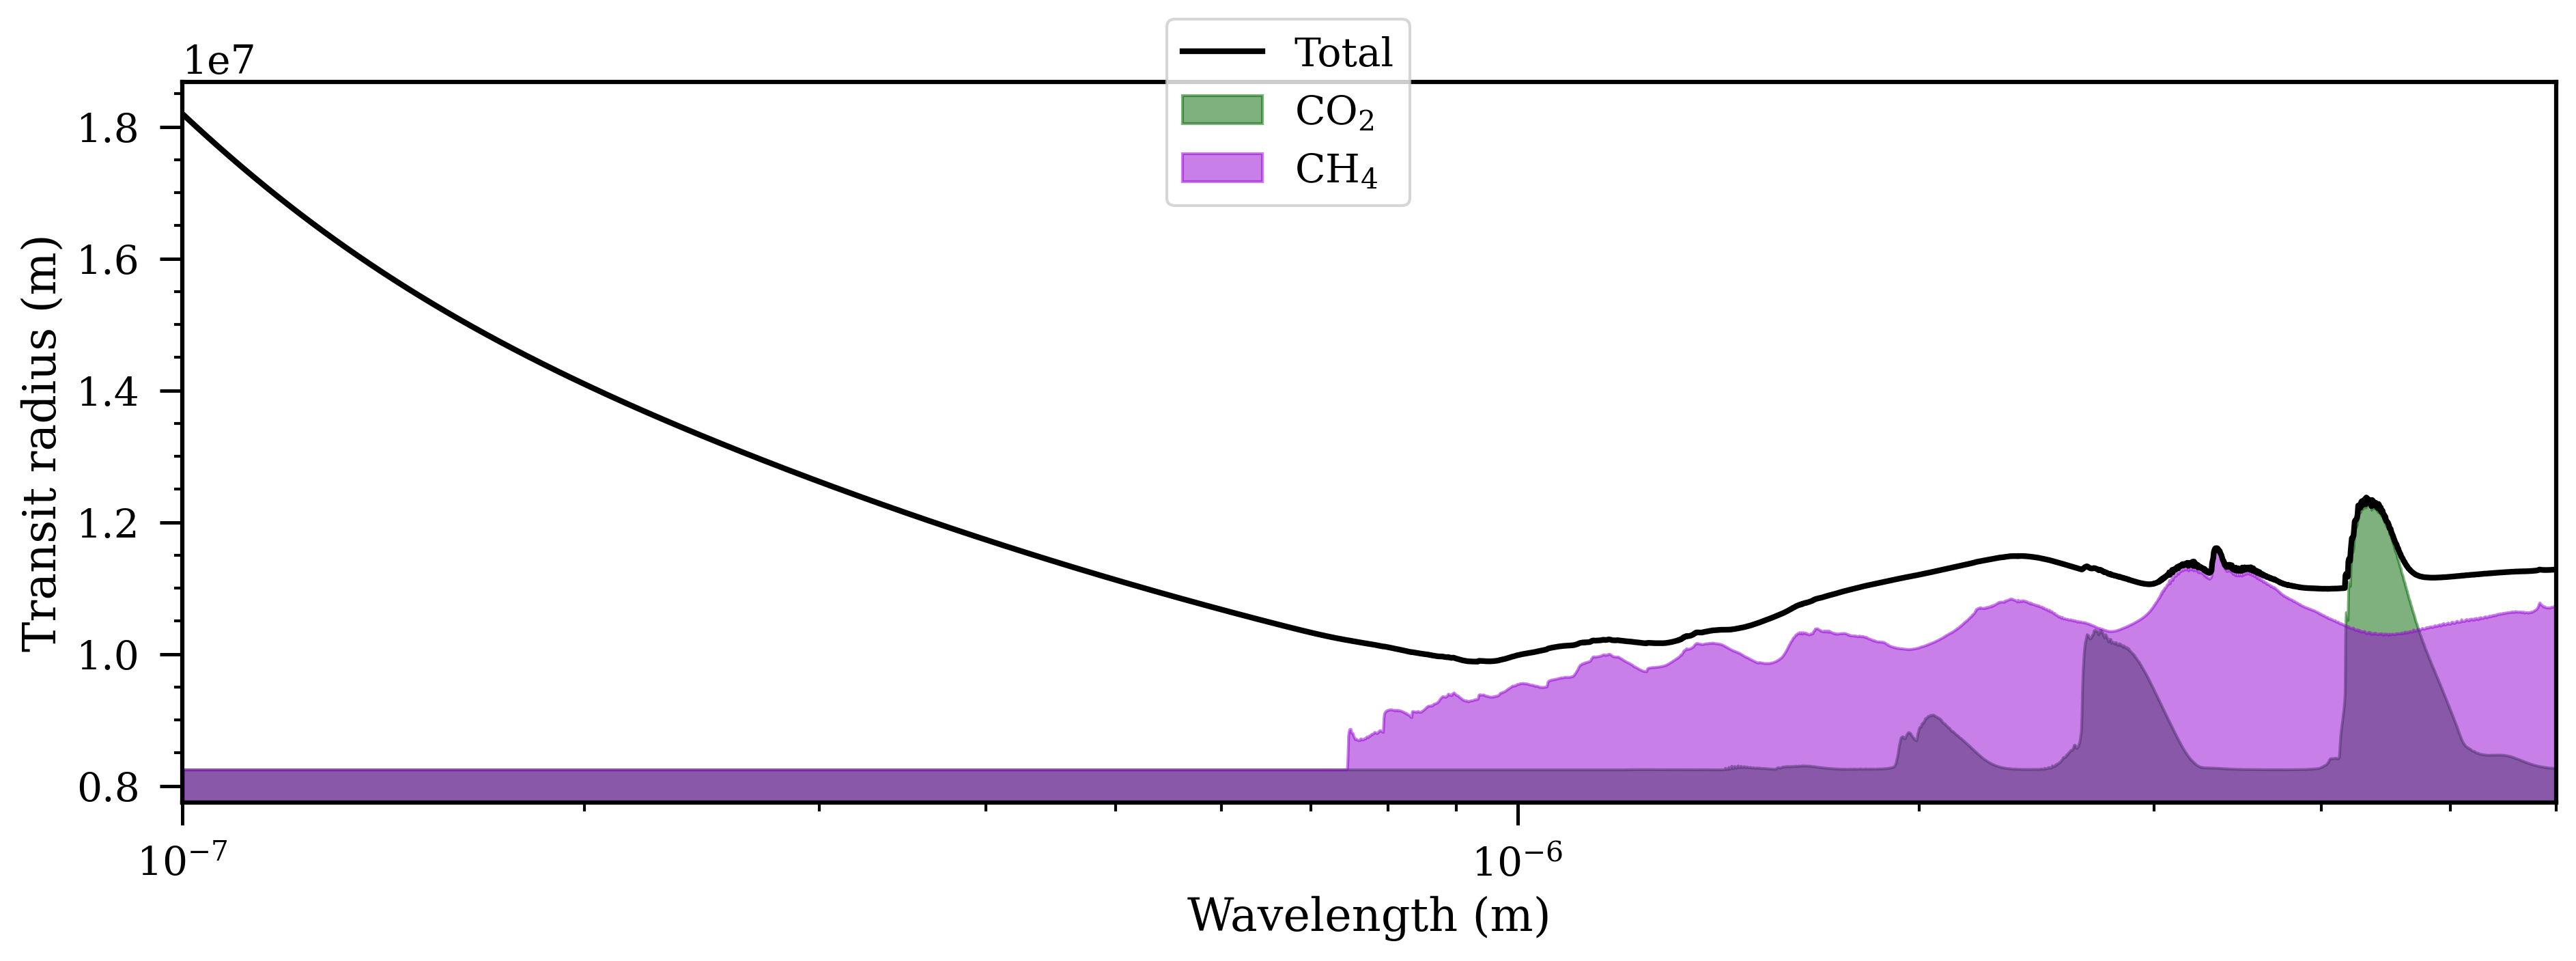

In [10]:
radtrans_obj = Radtrans(
    pressures=np.logspace(-6, 2, 100),
    line_species=[
        'CO2',
        'CH4'
    ],
    rayleigh_species=['H2', 'He'],
    gas_continuum_contributors=['H2--H2', 'H2--He'],
    wavelength_boundaries=[0.1, 6]
)

opacity_contributions = plot_opacity_contributions(
    radtrans_obj,
    mode='transmission',  # can also be 'emission'
    exclude=['H2 (Rayleigh)', 'He (Rayleigh)', 'H2--H2', 'H2--He'],
    colors={
        'Total': 'k',
        'line_species': {
            'CO2' : 'darkgreen',
            'CH4' : 'darkviolet'
        }
    },
    fill_below=True,  # if False, contributions are represented as cruves instead as a filled area
    x_axis_scale='log',  # 'linear' by default
    temperatures=spectral_model_chem_eq.temperatures,
    mass_fractions=spectral_model_chem_eq.mass_fractions,
    mean_molar_masses=spectral_model_chem_eq.mean_molar_masses,
    reference_gravity=toi396b.reference_gravity,
    planet_radius=toi396b.radius,
    reference_pressure=toi396b.reference_pressure
)